In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import matplotlib.pyplot as plt
import tensorflow as tf
from keras import Input
from keras.models import Sequential
from keras.models import Model
from keras.layers import Conv1D, Conv2D, Dense, Dropout, BatchNormalization, Flatten, MaxPooling2D, Activation
from keras import utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, accuracy_score, ConfusionMatrixDisplay

In [5]:
#download the weather images and put them in a directory
path = r"~/Documents/Career Foundry/specialization/Data Sets/Unsupervised/Weather"
folders = os.listdir(path)
print(folders)

['Rain', 'Cloudy', 'Sunrise', 'Shine']


In [6]:
#this will load in the pictures and rescale them to 250x250pixels

datagenerator = ImageDataGenerator(rescale=1/255, validation_split=0.2)
train_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='training',
)

test_generator = datagenerator.flow_from_directory(
    path,
    target_size=(250 , 250),
    batch_size=32,
    subset='validation',
)

Found 901 images belonging to 4 classes.
Found 224 images belonging to 4 classes.


In [7]:
#this is a CNN to categorize the weather images

inputs = Input(shape=(250, 250, 3))

x = Conv2D(32, (5,5), activation = 'relu')(inputs)
x = MaxPooling2D(3,3)(x)
x = Conv2D(64, (5,5) , activation = 'relu')(x)
x = MaxPooling2D((3,3))(x)
x = Conv2D(128 , (5,5) , activation = 'relu')(x)
x = MaxPooling2D(3,3)(x)
x = Flatten()(x)
x = Dropout(0.5, seed = 5)(x)
x = Dense(128 , activation = 'relu')(x)

outputs = Dense(4, activation = 'softmax')(x)

model:Model = Model(inputs=inputs, outputs=outputs)

2025-08-01 11:42:43.273083: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 4, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/4


/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.4880 - loss: 0.1448 - val_accuracy: 0.6473 - val_loss: 0.1305
Epoch 2/4
 1/28 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.6562 - loss: 0.1398

/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 177ms/step - accuracy: 0.6562 - loss: 0.1398 - val_accuracy: 0.6562 - val_loss: 0.1292
Epoch 3/4
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.7294 - loss: 0.0961 - val_accuracy: 0.7857 - val_loss: 0.0894
Epoch 4/4
28/28 ━━━━━━━━━━━━━━━━━━━━ 17s 489ms/step - accuracy: 0.8438 - loss: 0.0631 - val_accuracy: 0.7321 - val_loss: 0.1103


In [9]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 10, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - accuracy: 0.7629 - loss: 0.0855 - val_accuracy: 0.7723 - val_loss: 0.0962
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 281ms/step - accuracy: 0.9062 - loss: 0.0321 - val_accuracy: 0.7455 - val_loss: 0.1008
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 106s 4s/step - accuracy: 0.8529 - loss: 0.0599 - val_accuracy: 0.7768 - val_loss: 0.0855
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 130ms/step - accuracy: 0.8438 - loss: 0.0587 - val_accuracy: 0.7902 - val_loss: 0.0788
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 78s 3s/step - accuracy: 0.8269 - loss: 0.0654 - val_accuracy: 0.7991 - val_loss: 0.0804
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 455ms/step - accuracy: 0.7500 - loss: 0.0835 - val_accuracy: 0.7946 - val_loss: 0.0854
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 96s 3s/step - accuracy: 0.8548 - loss: 0.0627 - val_accuracy: 0.7098 - val_loss: 0.1249
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 211ms/step - accuracy: 0.7500 - loss: 0.0685 - val_accuracy: 0.7188 

In [10]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 20, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 77s 3s/step - accuracy: 0.8395 - loss: 0.0601 - val_accuracy: 0.7589 - val_loss: 0.0943
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 346ms/step - accuracy: 0.9375 - loss: 0.0423 - val_accuracy: 0.7411 - val_loss: 0.1006
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.8580 - loss: 0.0539 - val_accuracy: 0.7768 - val_loss: 0.0965
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 225ms/step - accuracy: 0.8438 - loss: 0.0639 - val_accuracy: 0.7812 - val_loss: 0.0928
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 72s 3s/step - accuracy: 0.8580 - loss: 0.0499 - val_accuracy: 0.8616 - val_loss: 0.0519
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 210ms/step - accuracy: 0.9062 - loss: 0.0329 - val_accuracy: 0.8393 - val_loss: 0.0606
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 98s 4s/step - accuracy: 0.9200 - loss: 0.0297 - val_accuracy: 0.8036 - val_loss: 0.0673
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 410ms/step - accuracy: 0.9062 - loss: 0.0275 - val_accuracy: 0.8125 

In [19]:
#compile and run the model
#how many epochs are required to generate an accurate model?

model.compile(optimizer="Adam", loss="mean_squared_error", metrics=["accuracy"])
model.fit(
    train_generator, 
    epochs = 50, #<----FILL THIS IN!
    steps_per_epoch = train_generator.n // train_generator.batch_size,
    validation_data = test_generator,
    validation_steps = test_generator.n // test_generator.batch_size,
)

Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 71s 3s/step - accuracy: 0.8624 - loss: 0.0537 - val_accuracy: 0.8438 - val_loss: 0.0626
Epoch 2/50
 1/28 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.9375 - loss: 0.0261

/home/scruffy/anaconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 187ms/step - accuracy: 0.9375 - loss: 0.0261 - val_accuracy: 0.8438 - val_loss: 0.0632
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.9226 - loss: 0.0307 - val_accuracy: 0.8839 - val_loss: 0.0484
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 18s 513ms/step - accuracy: 0.8438 - loss: 0.0456 - val_accuracy: 0.8839 - val_loss: 0.0468
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 73s 3s/step - accuracy: 0.9323 - loss: 0.0269 - val_accuracy: 0.8571 - val_loss: 0.0589
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 170ms/step - accuracy: 0.9375 - loss: 0.0091 - val_accuracy: 0.8125 - val_loss: 0.0815
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.9377 - loss: 0.0268 - val_accuracy: 0.8259 - val_loss: 0.0672
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 485ms/step - accuracy: 0.6000 - loss: 0.1358 - val_accuracy: 0.8438 - val_loss: 0.0628
Epoch 9/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 87s 3s/step - accuracy: 0.9088 - loss: 0.0376 - val_accuracy: 0.8080 - val_loss: 

In [20]:
results = pd.DataFrame(model.history.history)

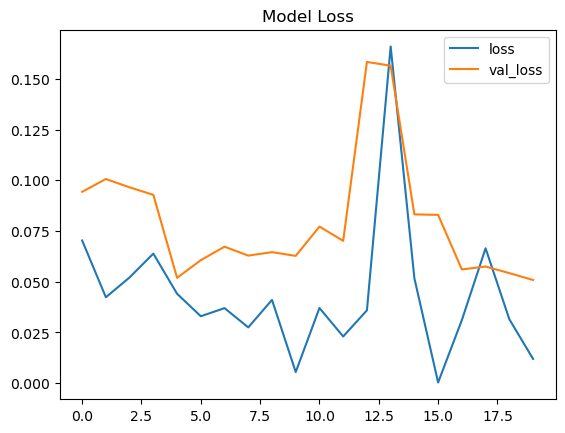

In [12]:
results[['loss','val_loss']].plot(title='Model Loss')
plt.savefig('./loss50.png')

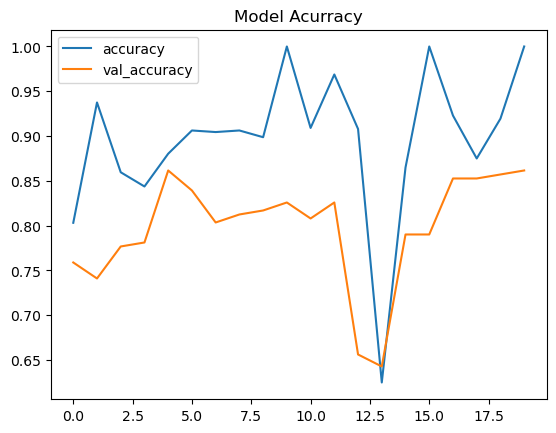

In [13]:
results[['accuracy','val_accuracy']].plot(title='Model Acurracy')
plt.savefig('./accuracy.png')

In [14]:
# Print the accuracy and loss
print("Accuracy: {}, Val_Accuracy: {}".format(results['accuracy'].iloc[-1], results['val_accuracy'].iloc[-1]))
print("Loss: {}, Val_Loss: {}".format(results['loss'].iloc[-1], results['val_loss'].iloc[-1]))

Accuracy: 1.0, Val_Accuracy: 0.8616071343421936
Loss: 0.01190478727221489, Val_Loss: 0.05083344504237175


11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 279ms/step


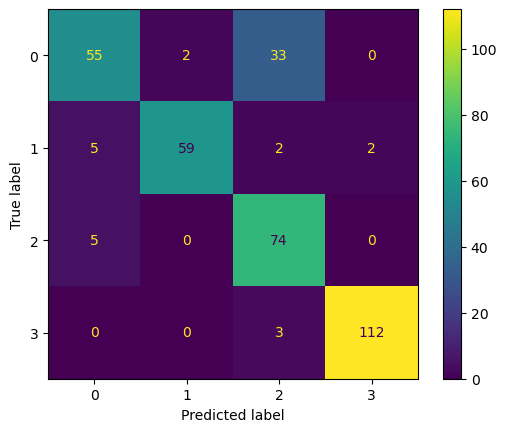

In [15]:
# collect n batches of images and display the confusion matrix for them.

class_names = ['Cloudy', 'Rain', 'Shine', 'Sunrise']
n = 10 #<--you can change the number of batches selected.

image_batch, classes_batch = next(test_generator)

for batch in range(n):
    temp = next(test_generator)
    image_batch = np.concatenate((image_batch, temp[0]))
    classes_batch = np.concatenate((classes_batch, temp[1]))

classes_batch = classes_batch
y_predict = model.predict(image_batch)

#Confusion matrix for training data
cm = confusion_matrix(y_pred = [np.argmax(x) for x in y_predict], y_true = [np.argmax(x) for x in classes_batch])
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [16]:
#This function will display a number of random images as well as the predictions for the type of weather.

def predict_one(model, num_images = None):  
    image_batch, classes_batch = next(test_generator)
    predicted_batch = model.predict(image_batch)
    for k in range(0,image_batch.shape[0] if num_images is None else num_images):
        image = image_batch[k]
        real_class = class_names[np.argmax(classes_batch[k])]
        predicted_class = class_names[np.argmax(predicted_batch[k])]
        value_predicted = predicted_batch[k]
        isTrue = (real_class == predicted_class)
        plt.figure(k)
        plt.title(str("Correct Prediction" if isTrue else "Incorrect Prediction") + ' - class: ' + real_class + ' - ' + 'predicted: ' + predicted_class + str(value_predicted))
        plt.axis('off')
        plt.savefig('./' + real_class + '_' + predicted_class + '_' + str(value_predicted) + '.png')
        plt.imshow(image)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step


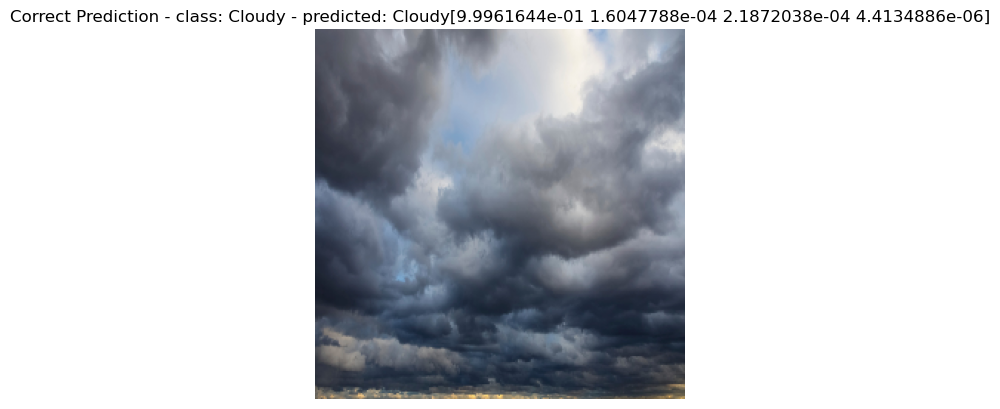

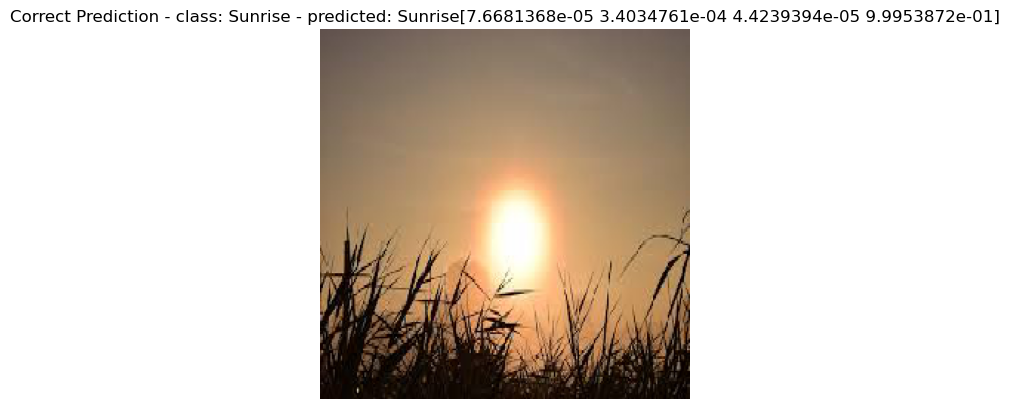

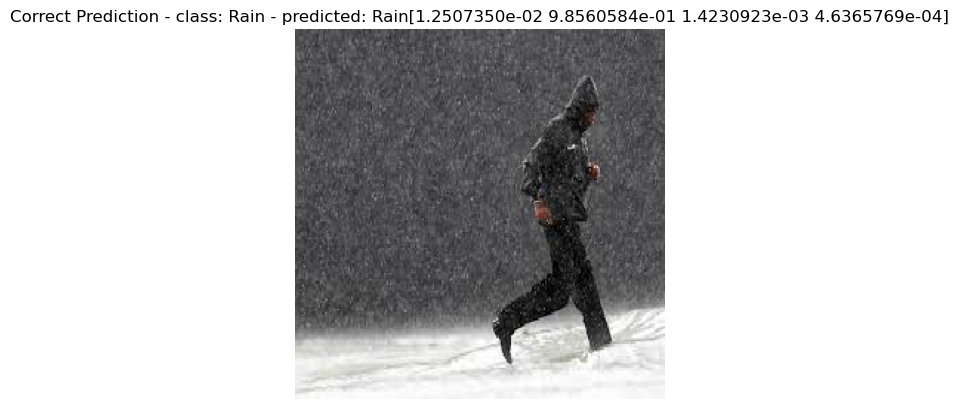

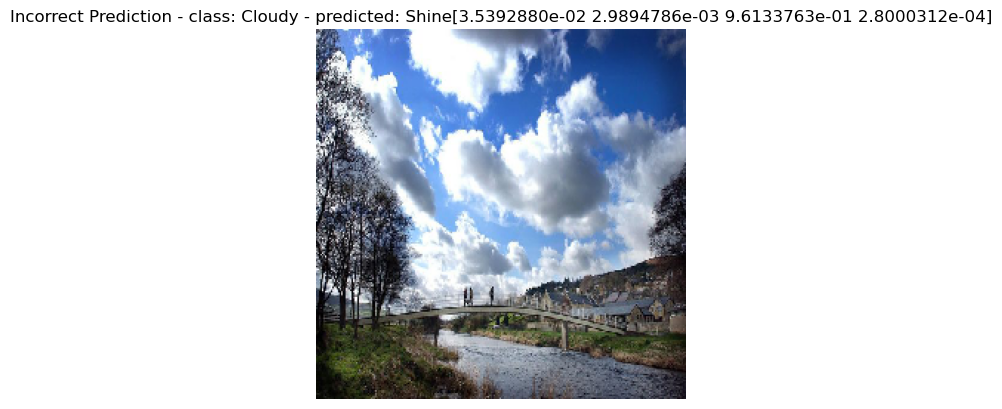

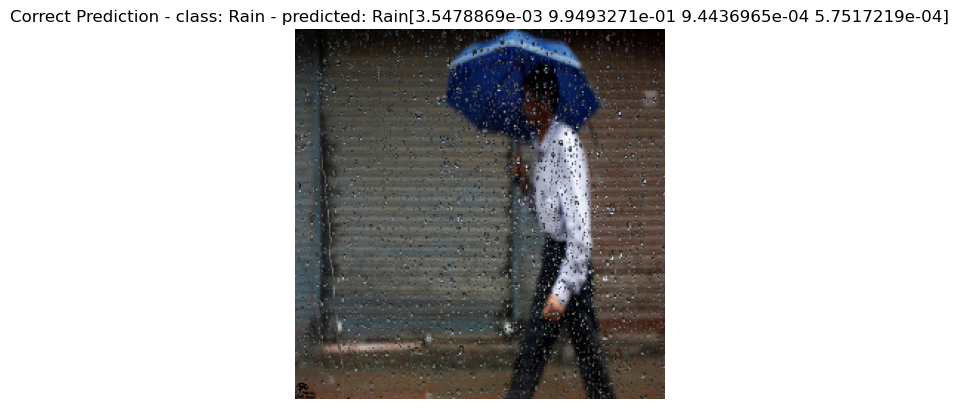

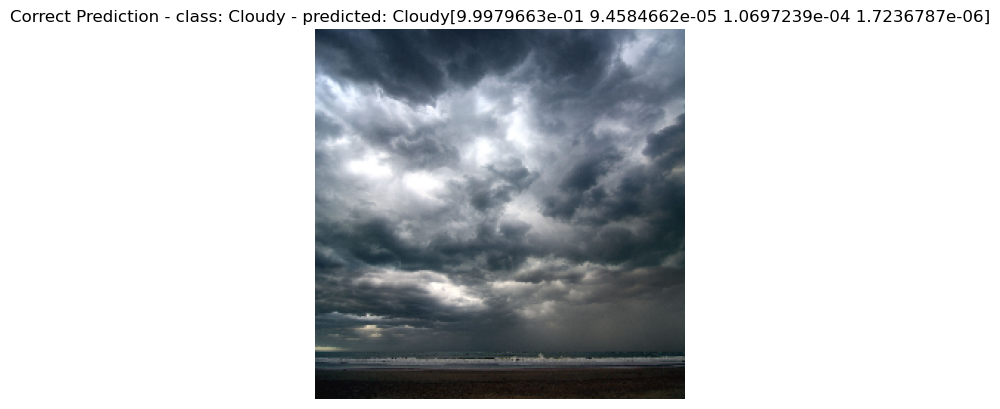

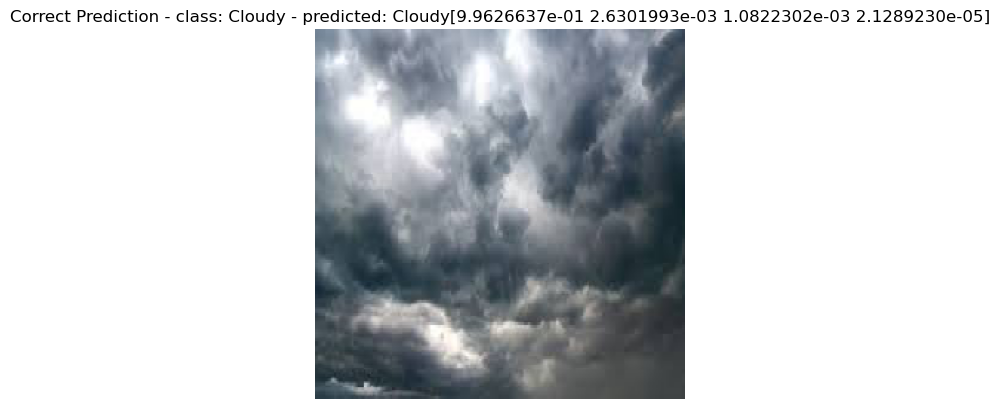

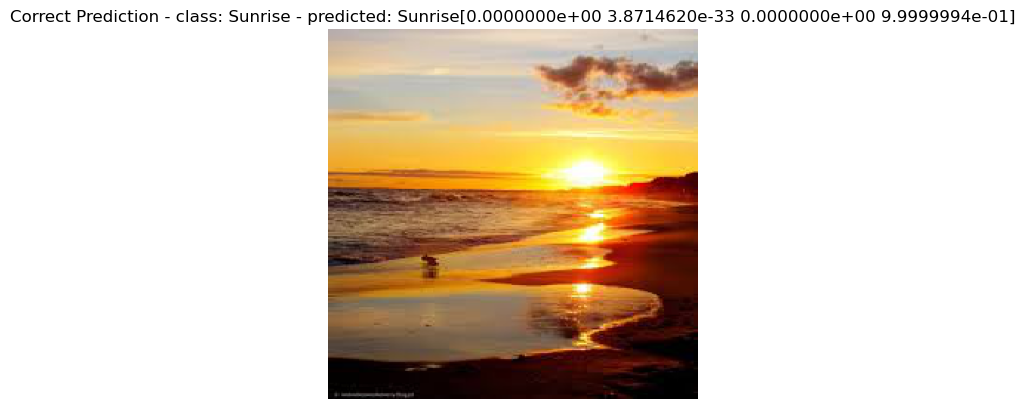

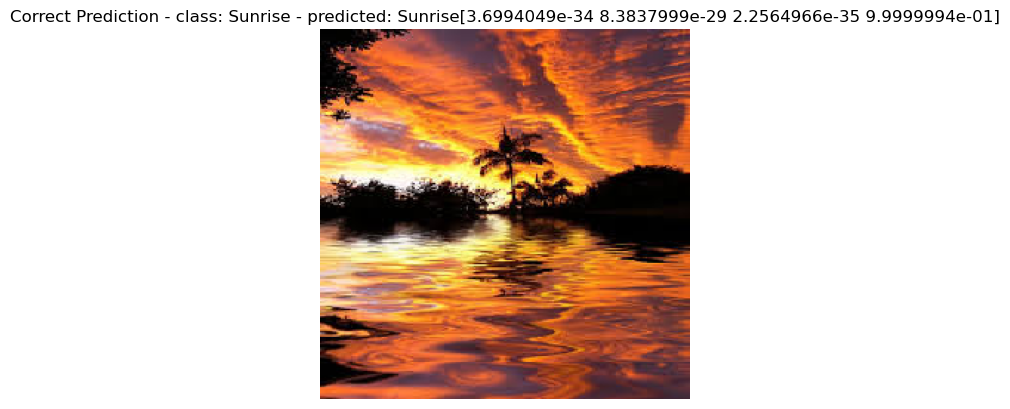

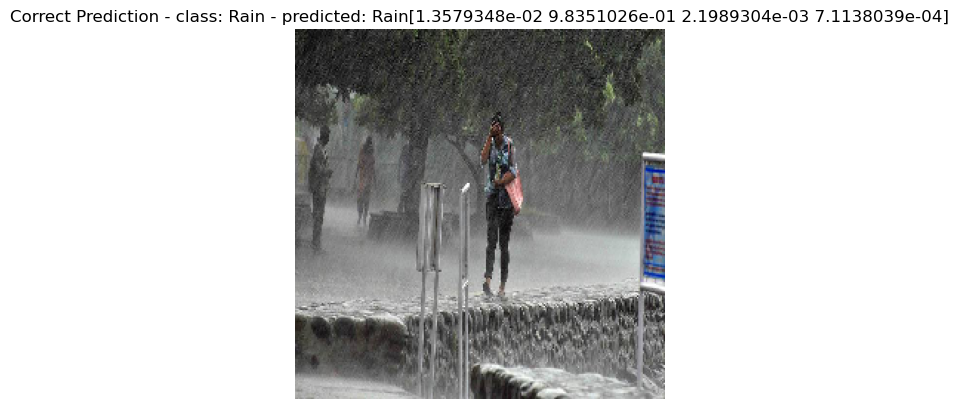

In [18]:
predict_one(model, 10) #<--you can show multiple pictures with this command. Just fill in the number you want to see.